# DataSet: India's 10 metro city aqi record since 2015 to 2023(Source: kaggle)

In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
import pandas as pd
dataset = pd.read_csv("/content/drive/My Drive/Data_Science/Assignment-1/india_city_aqi_2015_2023.csv")

In [32]:
print(dataset.shape)

(32870, 10)


In [33]:
print(list(dataset.columns))

['city', 'date', 'pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'aqi', 'aqi_category']


In [34]:
print(set(dataset["aqi_category"]))
print(set(dataset["city"]))

{'Good', 'Poor', 'Satisfactory', 'Moderate'}
{'Pune', 'Chennai', 'Kolkata', 'Mumbai', 'Lucknow', 'Delhi', 'Bengaluru', 'Hyderabad', 'Ahmedabad', 'Jaipur'}


In [35]:
print(dataset.head())

    city        date        pm25        pm10        no2        so2        co  \
0  Delhi  2015-01-01   99.868566  147.103280  49.715328  19.615149  0.729754   
1  Delhi  2015-01-02  143.168513  208.517207  32.957884  14.712800  0.660975   
2  Delhi  2015-01-03   89.678491  101.412886  14.126233   9.188562  0.496151   
3  Delhi  2015-01-04   43.679037   65.432963  61.984732  10.871118  0.820258   
4  Delhi  2015-01-05   58.224691  110.443143  22.735096  13.878490  0.619808   

          o3  aqi  aqi_category  
0  46.487946  103      Moderate  
1  43.014054  141      Moderate  
2  54.713710   82  Satisfactory  
3  28.628777   50          Good  
4  45.624594   69  Satisfactory  


# Cleaning

In [61]:
print(dataset.isnull().sum())

city            0
date            0
pm25            0
pm10            0
no2             0
so2             0
co              0
o3              0
aqi             0
aqi_category    0
dtype: int64


In [62]:
print(dataset.duplicated().sum())

0


# Analysis


In [36]:
print(dataset["aqi_category"].value_counts())

aqi_category
Satisfactory    17244
Moderate        11433
Good             4183
Poor               10
Name: count, dtype: int64



    Good: 0-50
    Satisfactory: 51-100
    Moderate: 101-200
    Poor: 201-300
    Very Poor: 301-400
    Severe: 401-500


/tmp/ipykernel_683/4279977910.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataset, x='aqi_category', palette='viridis')


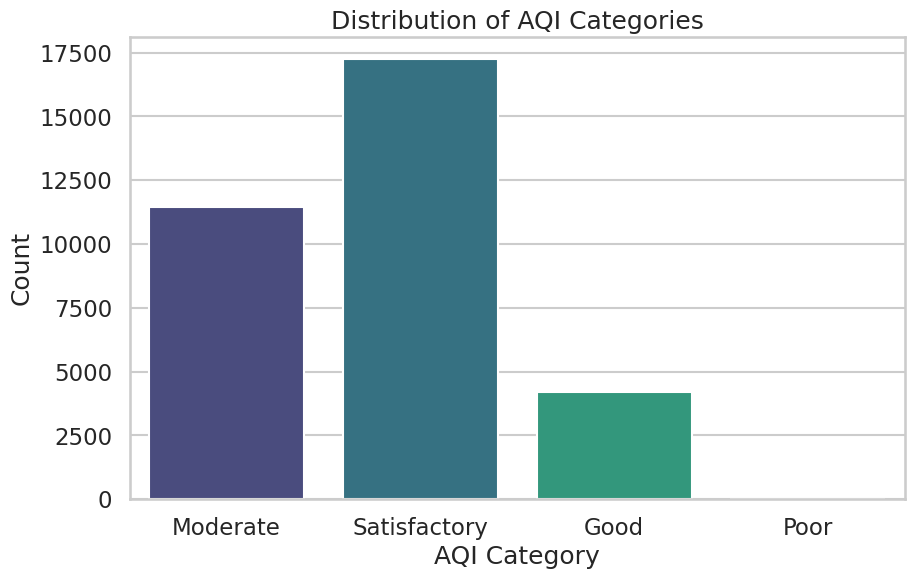

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=dataset, x='aqi_category', palette='viridis')
plt.title('Distribution of AQI Categories')
plt.xlabel('AQI Category')
plt.ylabel('Count')
plt.show()

In [39]:
print(dataset["aqi"].max())
print(dataset["aqi"].min())

221
11


# Average AQI

In [40]:
print(dataset["aqi"].mean())
print(dataset["aqi"].median())

88.12266504411318
88.0


In [41]:
arr = ["aqi", "no2", "so2", "co", "o3", "pm25", "pm10"]
for i in arr:
  print(i)
  print("=============================================================")
  mean = dataset[i].mean()
  median = dataset[i].median()
  std = dataset[i].std()
  var = dataset[i].var()
  q1 = dataset[i].quantile(0.25)
  q2 = dataset[i].quantile(0.50)
  q3 = dataset[i].quantile(0.75)
  iqr = q3 - q1

  lower_bound = q1 - 1.5 * iqr
  upper_bound = q3 + 1.5 * iqr

  print(f"Mean: {mean}")
  print(f"Median: {median}")
  print(f"Standard Deviation: {std}")
  print(f"Variance: {var}")
  print(f"Q1: {q1}")
  print(f"Q2 (Median): {q2}")
  print(f"Q3: {q3}")
  print(f"IQR: {iqr}")
  print(f"Lower Bound (Q1 - 1.5*IQR): {lower_bound}")
  print(f"Upper Bound (Q3 + 1.5*IQR): {upper_bound}")
  print("=============================================================")

aqi
Mean: 88.12266504411318
Median: 88.0
Standard Deviation: 31.895406688074743
Variance: 1017.3169677976831
Q1: 65.0
Q2 (Median): 88.0
Q3: 110.0
IQR: 45.0
Lower Bound (Q1 - 1.5*IQR): -2.5
Upper Bound (Q3 + 1.5*IQR): 177.5
no2
Mean: 40.16547158301505
Median: 40.14152462189468
Standard Deviation: 14.849411263611584
Variance: 220.50501487587456
Q1: 29.99018341954671
Q2 (Median): 40.14152462189468
Q3: 50.19085986696769
IQR: 20.20067644742098
Lower Bound (Q1 - 1.5*IQR): -0.3108312515847622
Upper Bound (Q3 + 1.5*IQR): 80.49187453809917
so2
Mean: 11.998475871193452
Median: 11.977979410352571
Standard Deviation: 4.882239477372629
Variance: 23.836262314415762
Q1: 8.570939240787487
Q2 (Median): 11.977979410352571
Q3: 15.31502834131893
IQR: 6.744089100531443
Lower Bound (Q1 - 1.5*IQR): -1.5451944100096782
Upper Bound (Q3 + 1.5*IQR): 25.431161992116095
co
Mean: 0.8021182598215701
Median: 0.8001373441918564
Standard Deviation: 0.29815647729694017
Variance: 0.0888972849541208
Q1: 0.5999759494039246

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ipywidgets as widgets
from IPython.display import display

sns.set(style="whitegrid", context="talk")

def plot_box(column):
    data = dataset[column].dropna()

    q1 = np.percentile(data, 25)
    q2 = np.percentile(data, 50)
    q3 = np.percentile(data, 75)
    mean = np.mean(data)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    plt.figure(figsize=(8, 6))

    ax = sns.boxplot(
        y=data,
        color="#4C72B0",
        width=0.4,
        fliersize=5,
        linewidth=2,
        showmeans=True,
        meanprops={
            "marker": "D",
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markersize": 8
        }
    )

    # Add statistic lines
    plt.axhline(q1, color='orange', linestyle='--', linewidth=2, label=f'Q1: {q1:.2f}')
    plt.axhline(q2, color='green', linestyle='-', linewidth=2, label=f'Median: {q2:.2f}')
    plt.axhline(q3, color='orange', linestyle='--', linewidth=2, label=f'Q3: {q3:.2f}')
    plt.axhline(mean, color='purple', linestyle='-.', linewidth=2, label=f'Mean: {mean:.2f}')
    plt.axhline(lower_bound, color='red', linestyle=':', linewidth=2, label='Lower Bound')
    plt.axhline(upper_bound, color='red', linestyle=':', linewidth=2, label='Upper Bound')

    plt.title(f"Boxplot of {column}", fontsize=16, fontweight='bold')
    plt.ylabel(f"{column} Value", fontsize=12)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

# Dropdown selector
dropdown = widgets.Dropdown(
    options=arr,
    description='Select Column:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='50%')
)

widgets.interactive(plot_box, column=dropdown)


interactive(children=(Dropdown(description='Select Column:', layout=Layout(width='50%'), options=('aqi', 'no2'…

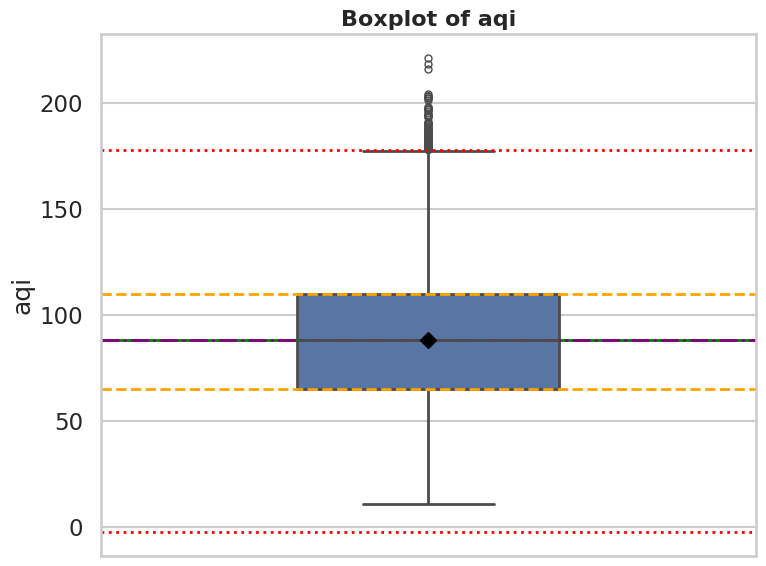

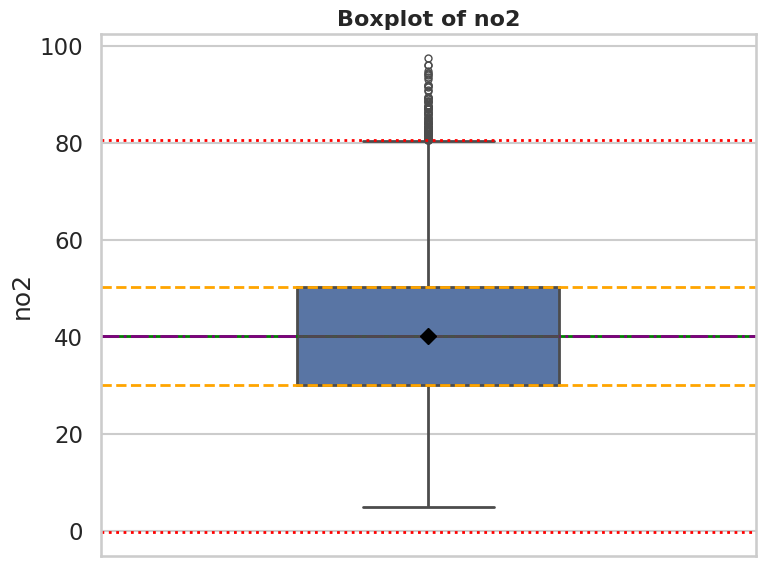

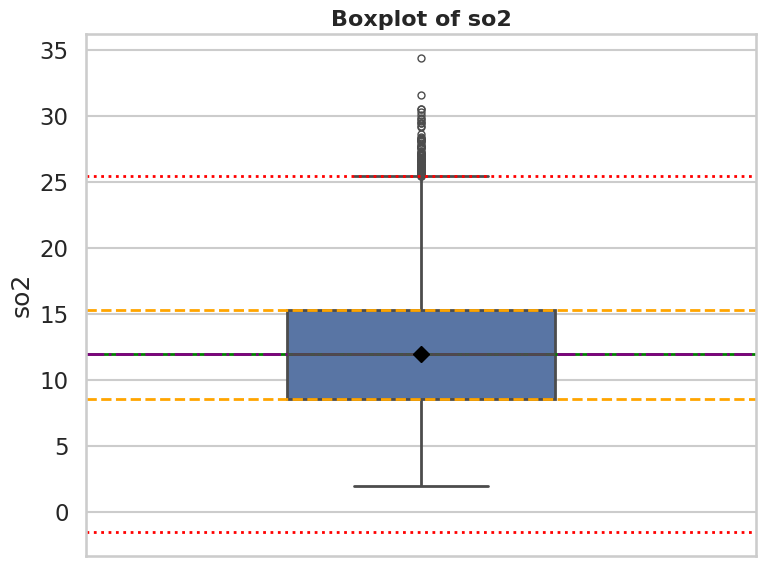

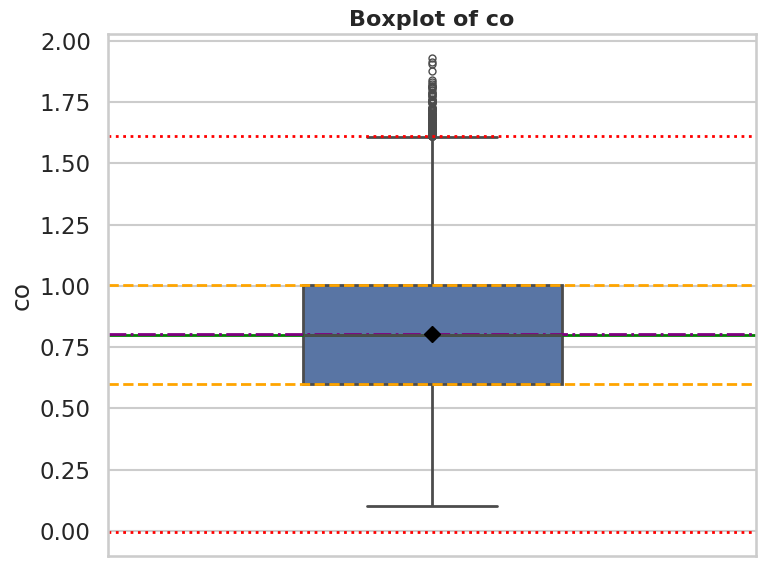

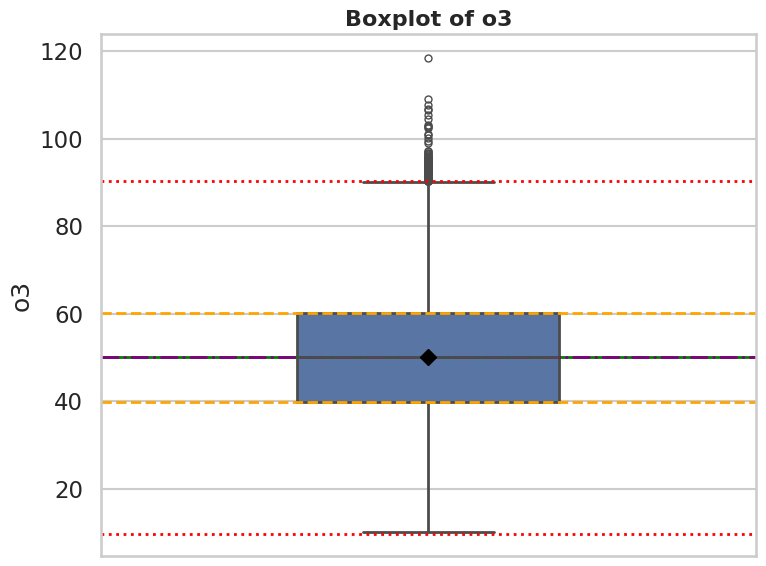

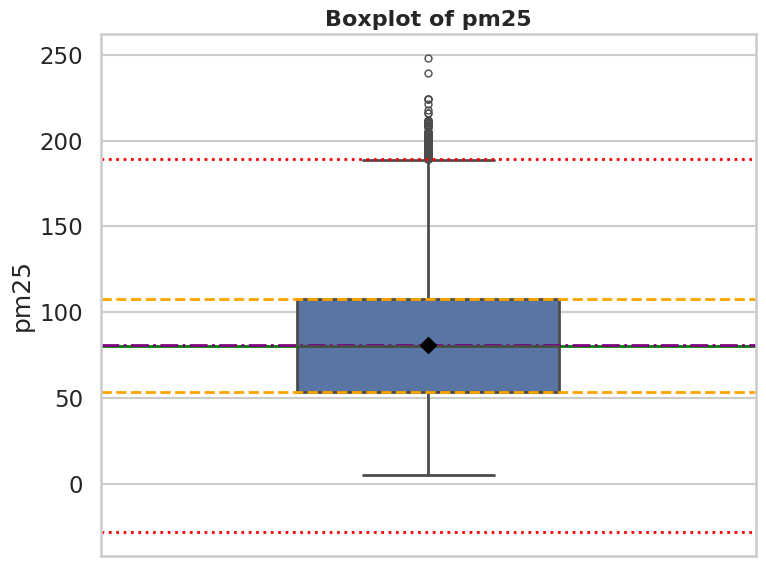

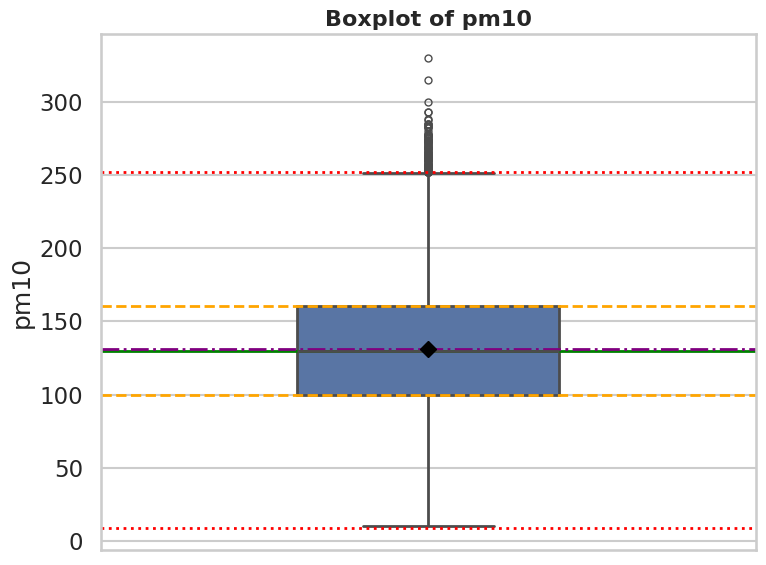

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid", context="talk")

for column in arr:

    data = dataset[column].dropna()

    q1 = np.percentile(data, 25)
    q2 = np.percentile(data, 50)
    q3 = np.percentile(data, 75)
    mean = np.mean(data)

    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    plt.figure(figsize=(8,6))

    sns.boxplot(
        y=data,
        color="#4C72B0",
        width=0.4,
        fliersize=5,
        linewidth=2,
        showmeans=True,
        meanprops={
            "marker": "D",
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markersize": 8
        }
    )

    # Statistical lines
    plt.axhline(q1, color='orange', linestyle='--', linewidth=2)
    plt.axhline(q2, color='green', linestyle='-', linewidth=2)
    plt.axhline(q3, color='orange', linestyle='--', linewidth=2)
    plt.axhline(mean, color='purple', linestyle='-.', linewidth=2)
    plt.axhline(lower_bound, color='red', linestyle=':', linewidth=2)
    plt.axhline(upper_bound, color='red', linestyle=':', linewidth=2)

    plt.title(f"Boxplot of {column}", fontsize=16, fontweight='bold')
    plt.ylabel(column)
    plt.tight_layout()
    plt.show()

In [44]:
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("Pandas display options set to show full tables.")

Pandas display options set to show full tables.


In [45]:
from scipy.stats import skew

for i in arr:
  print(i)
  print("=============================================================")
  print("Skewness:", skew(dataset[i]))
  print("=============================================================")

aqi
Skewness: 0.1472220193683187
no2
Skewness: 0.06551740826421645
so2
Skewness: 0.12121743558691242
co
Skewness: 0.05613633261177529
o3
Skewness: 0.013468106281150971
pm25
Skewness: 0.1521605183893069
pm10
Skewness: 0.12194138476240765


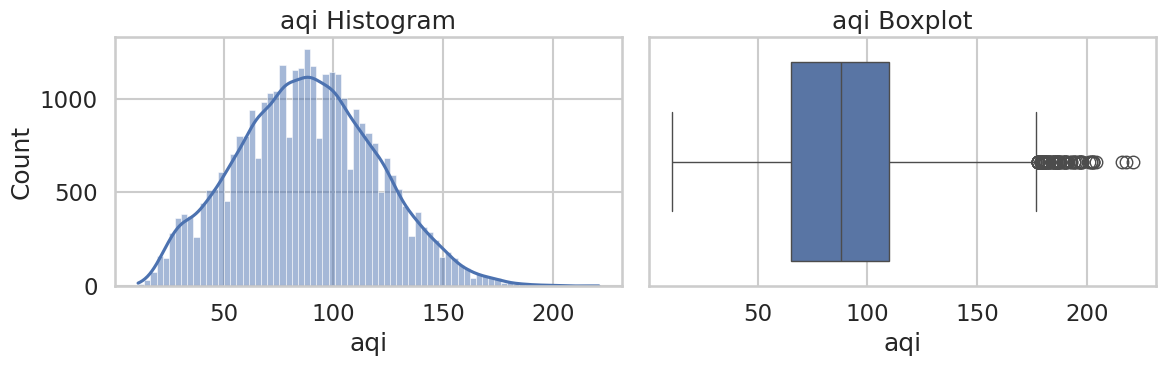

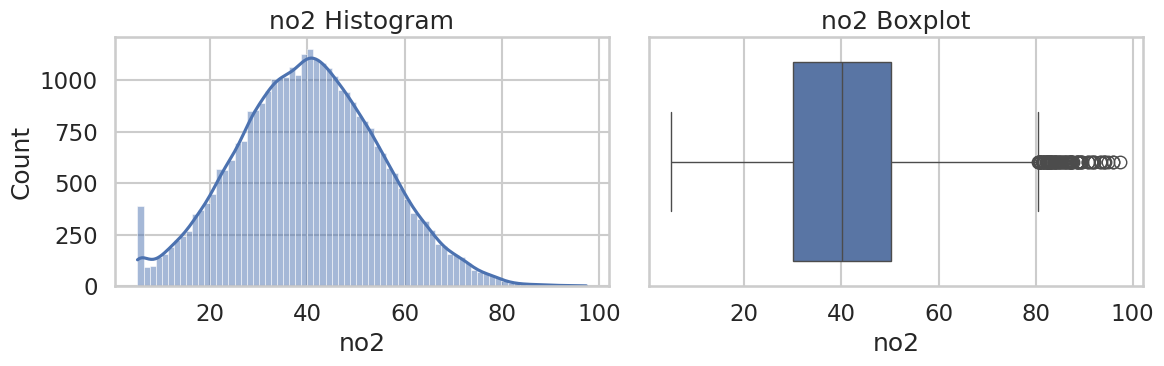

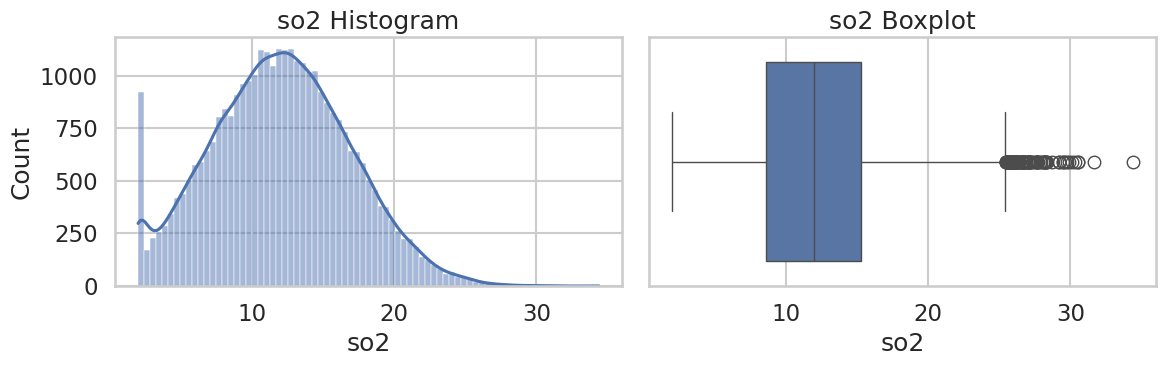

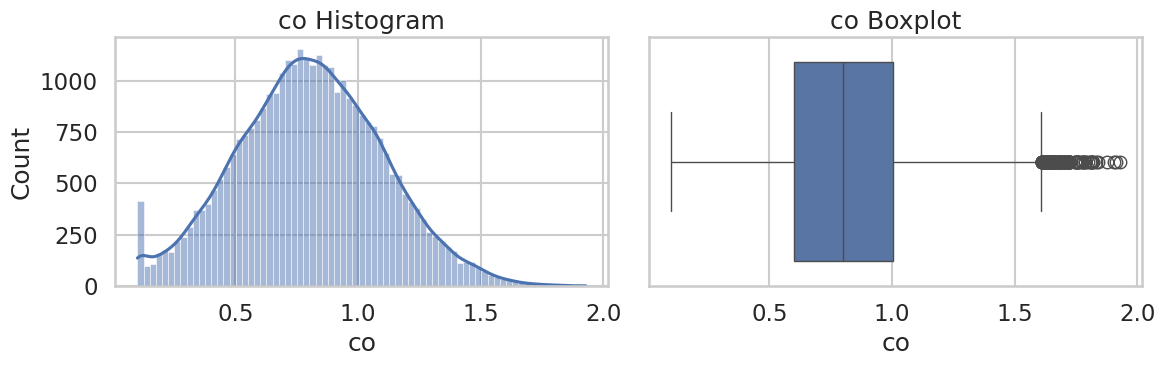

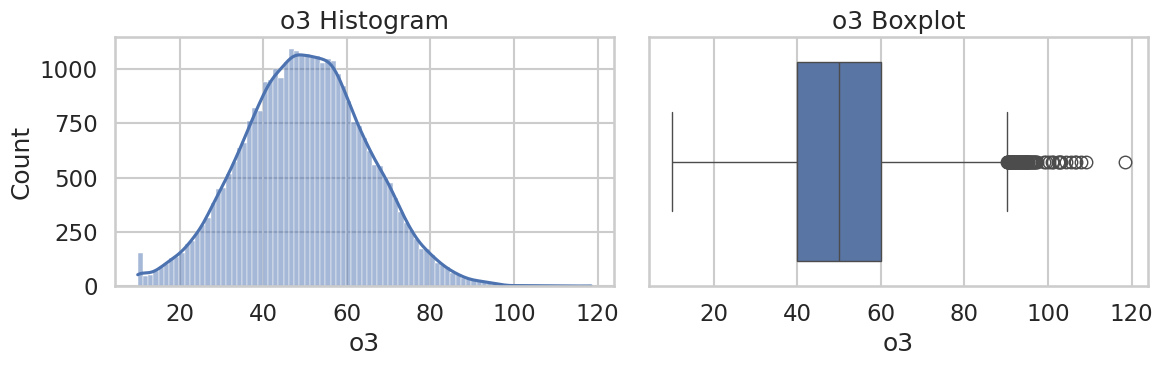

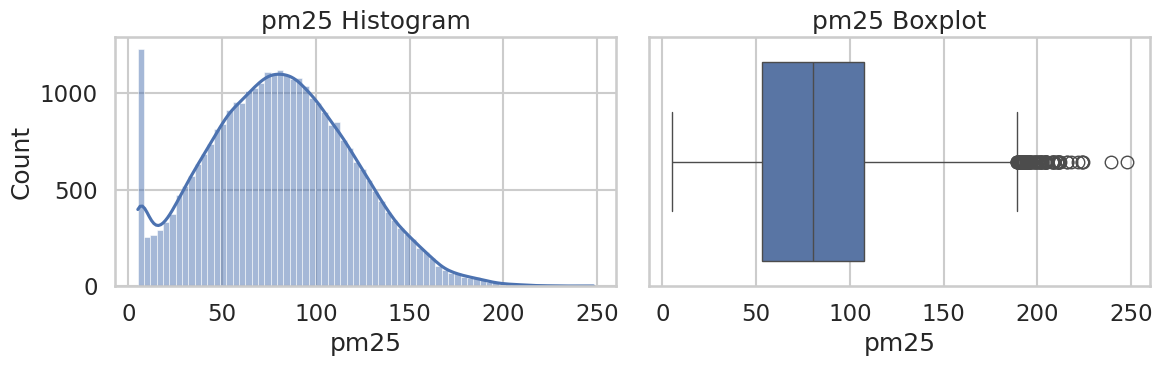

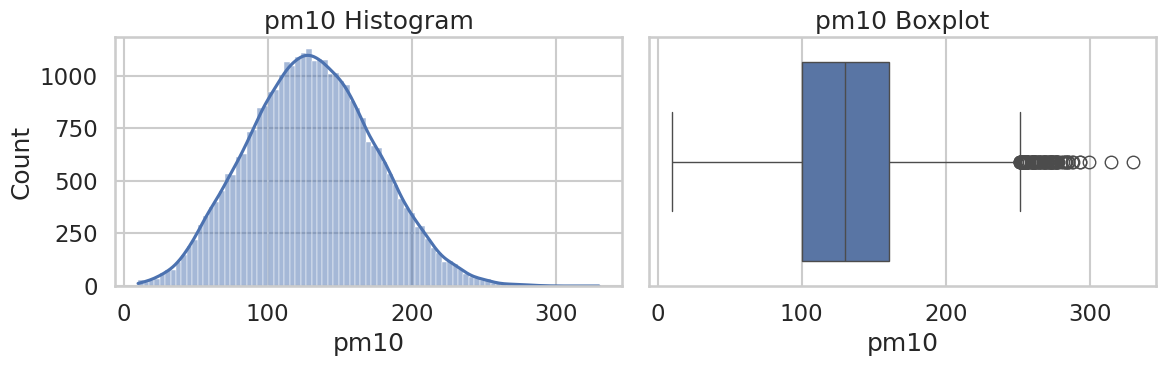

In [46]:
for col in arr:
    fig, axes = plt.subplots(1,2, figsize=(12,4))

    sns.histplot(dataset[col], kde=True, ax=axes[0])
    axes[0].set_title(f"{col} Histogram")

    sns.boxplot(x=dataset[col], ax=axes[1])
    axes[1].set_title(f"{col} Boxplot")

    plt.tight_layout()
    plt.show()


In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in arr:

    print(f"\n===== {col} =====")

    data = dataset[col].dropna()

    # IQR calculation
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Outlier detection
    outliers = dataset[(dataset[col] < lower) | (dataset[col] > upper)]

    print("Total Outliers:", len(outliers))

    # ---- Visualization ----
    plt.figure(figsize=(10,5))

    # Normal data
    sns.scatterplot(
        x=dataset.index,
        y=dataset[col],
        label="Normal Data"
    )

    # Outliers
    sns.scatterplot(
        x=outliers.index,
        y=outliers[col],
        color='red',
        label="Outliers",
        s=80
    )

    plt.title(f"Outlier Detection for {col}")
    plt.xlabel("Index")
    plt.ylabel(col)
    plt.legend()
    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

# Questions


# What is highest AQI of all the cities in years 2015-2023

In [48]:
def highest_aqi(dataset):
    res1 = dataset.groupby('city')['aqi'].max()
    res1 = res1.sort_values(ascending=False)
    print(res1)

highest_aqi(dataset)

city
Hyderabad    221
Bengaluru    218
Chennai      216
Jaipur       204
Mumbai       203
Kolkata      202
Lucknow      201
Delhi        198
Pune         198
Ahmedabad    195
Name: aqi, dtype: int64


# Lowest AQI of all the cities in years 2015-2023

In [49]:
def lowest_aqi(dataset):
    res1 = dataset.groupby('city')['aqi'].min()
    res1 = res1.sort_values(ascending=False)
    print(res1)

lowest_aqi(dataset)

city
Chennai      15
Ahmedabad    13
Bengaluru    13
Delhi        13
Hyderabad    13
Lucknow      13
Pune         13
Mumbai       13
Jaipur       11
Kolkata      11
Name: aqi, dtype: int64


# What is Average AQI of all the cities in years 2015-2023

In [50]:
def avg_aqi(dataset):
    res1 = dataset.groupby('city')['aqi'].mean()
    res1 = res1.sort_values(ascending=False)
    print(res1)

avg_aqi(dataset)

city
Hyderabad    88.883785
Pune         88.591421
Ahmedabad    88.525099
Bengaluru    88.386979
Kolkata      88.300578
Delhi        88.275936
Chennai      87.905689
Lucknow      87.884393
Jaipur       87.619410
Mumbai       86.853362
Name: aqi, dtype: float64


# What is Yearly Average AQI Trend (2015–2023)

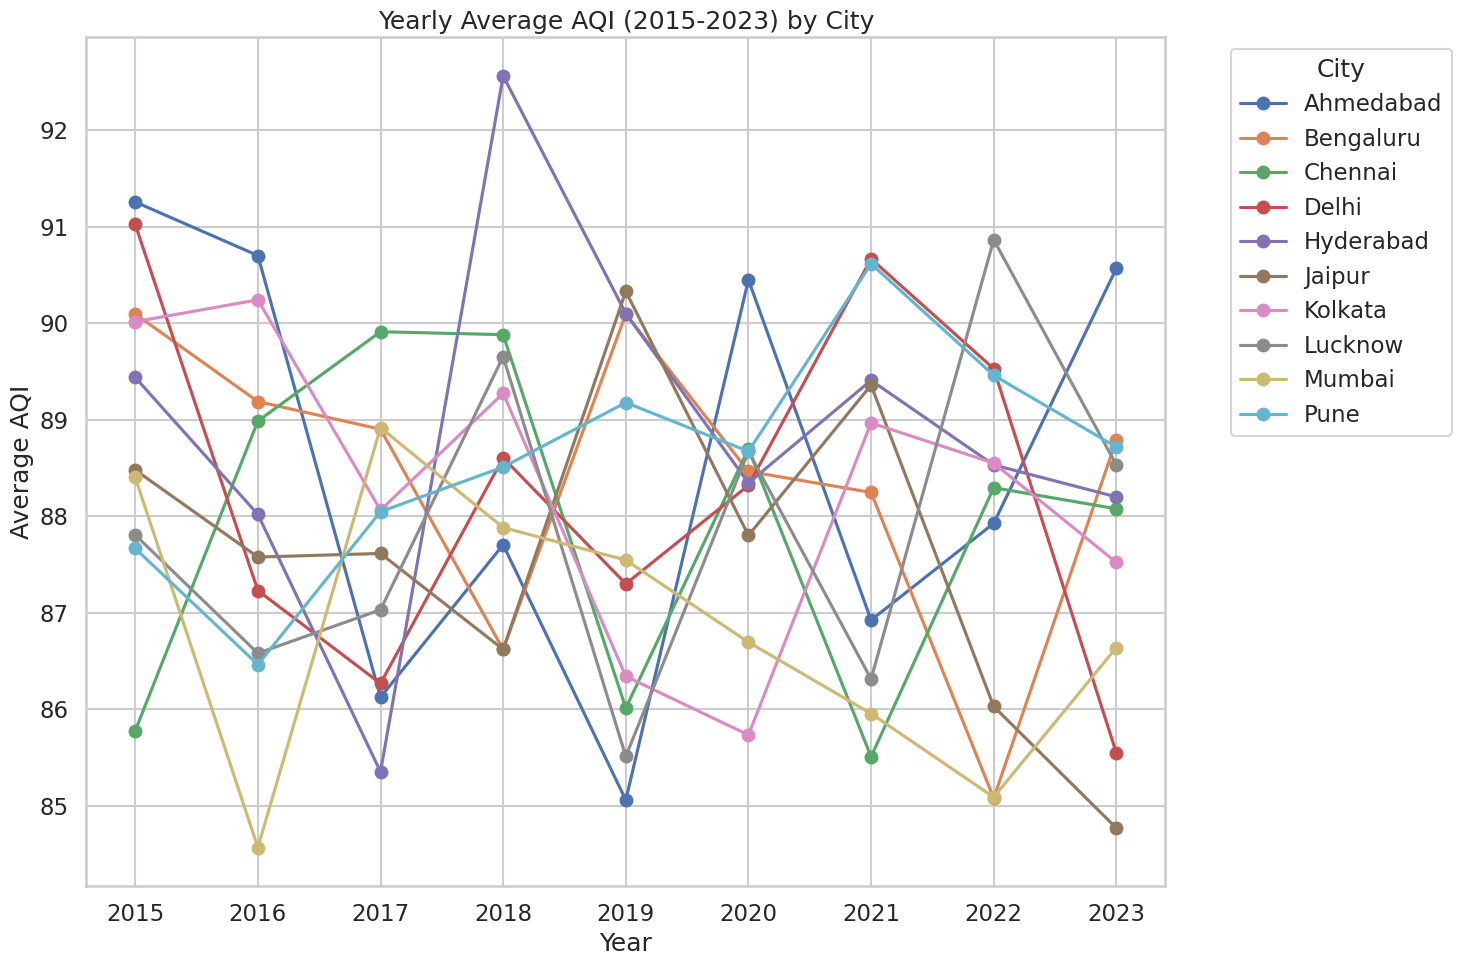

In [51]:
df = dataset.copy()

df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year

yearly_aqi = df.groupby(['city', 'year'])['aqi'].mean().reset_index()

pivot_table = yearly_aqi.pivot(index='year', columns='city', values='aqi')

plt.figure(figsize=(15, 10))

for city in pivot_table.columns:
    plt.plot(pivot_table.index, pivot_table[city], marker='o', label=city)

plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.title("Yearly Average AQI (2015-2023) by City")

plt.xticks(range(2015, 2024))

plt.legend(title="City", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#  Average AQI for Pre vs During vs Post COVID

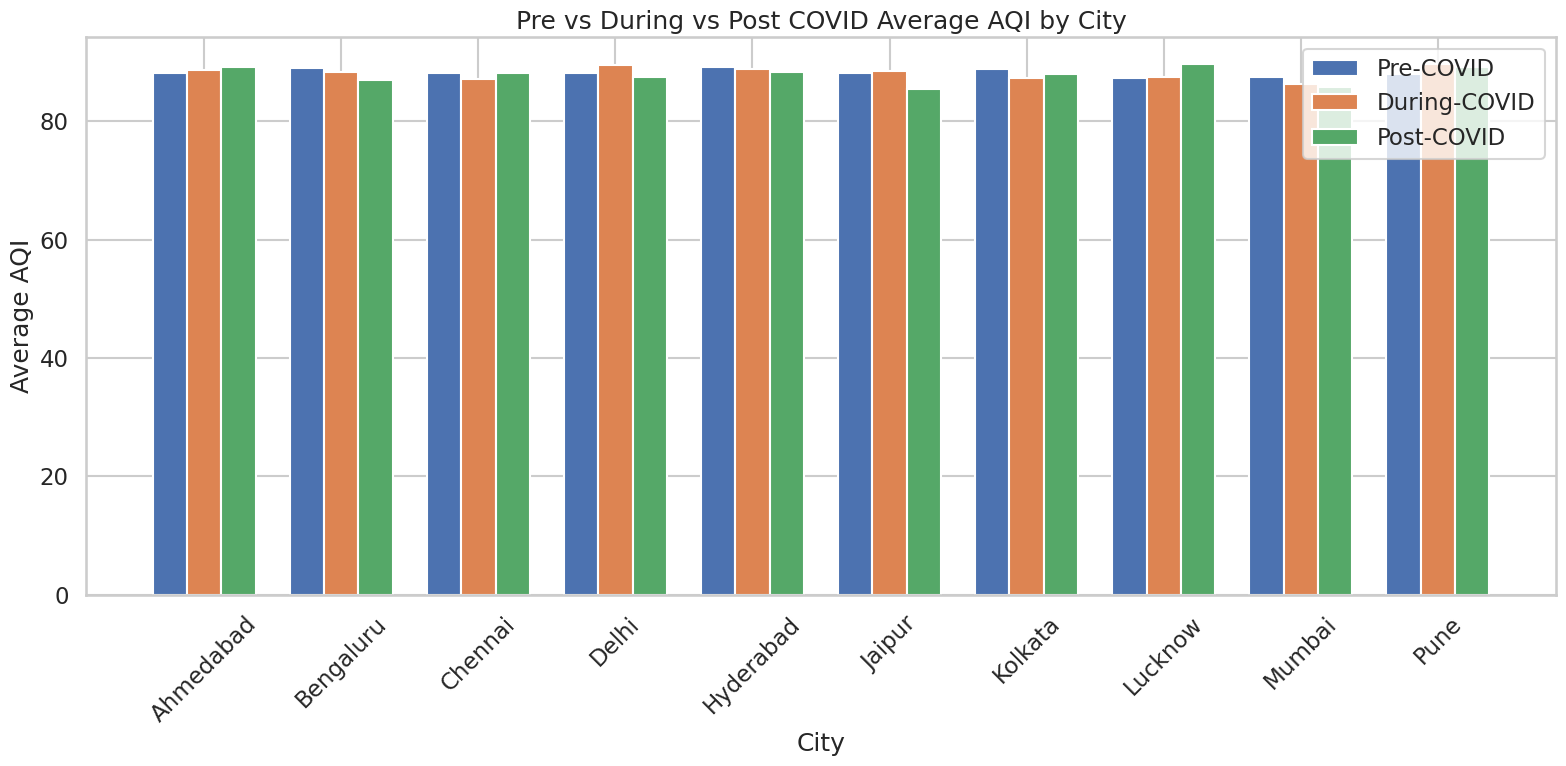

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = dataset.copy()

df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year

# Define COVID periods
def covid_period(year):
    if year <= 2019:
        return "Pre-COVID (2015-2019)"
    elif year <= 2021:
        return "During-COVID (2020-2021)"
    else:
        return "Post-COVID (2022-2023)"

df['period'] = df['year'].apply(covid_period)

# Calculate average AQI per city per period
period_aqi = df.groupby(['city', 'period'])['aqi'].mean().reset_index()

# Pivot table
comparison = period_aqi.pivot(index='city', columns='period', values='aqi')

cities = comparison.index
x = np.arange(len(cities))
width = 0.25   # smaller width since we now have 3 bars

plt.figure(figsize=(16, 8))

plt.bar(x - width, comparison["Pre-COVID (2015-2019)"], width, label="Pre-COVID")
plt.bar(x, comparison["During-COVID (2020-2021)"], width, label="During-COVID")
plt.bar(x + width, comparison["Post-COVID (2022-2023)"], width, label="Post-COVID")

plt.xlabel("City")
plt.ylabel("Average AQI")
plt.title("Pre vs During vs Post COVID Average AQI by City")

plt.xticks(x, cities, rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

Pollution Rebounded Quickly

In many Indian cities:

AQI dropped sharply during strict lockdown,
March–June 2020 (strict lockdown phase)

But industries, traffic, and construction resumed quickly

So post-lockdown AQI rose again

That reduces the overall difference.

# Has AQI improved or worsened from 2015 to 2023 in each city?

In [53]:
yearly_aqi = df.groupby(['city', 'year'])['aqi'].mean().reset_index()

aqi_2015 = yearly_aqi[yearly_aqi['year'] == 2015][['city', 'aqi']]
aqi_2023 = yearly_aqi[yearly_aqi['year'] == 2023][['city', 'aqi']]

comparison = pd.merge(aqi_2015, aqi_2023, on='city', suffixes=('_2015', '_2023'))

comparison['AQI Change (2023-2015)'] = comparison['aqi_2023'] - comparison['aqi_2015']

comparison['Status'] = comparison['AQI Change (2023-2015)'].apply(
    lambda x: 'Improved' if x < 0 else 'Worsened'
)

comparison = comparison.sort_values(by='AQI Change (2023-2015)')

print(comparison)

        city   aqi_2015   aqi_2023  AQI Change (2023-2015)    Status
3      Delhi  91.024658  85.545205               -5.479452  Improved
5     Jaipur  88.479452  84.767123               -3.712329  Improved
6    Kolkata  90.016438  87.520548               -2.495890  Improved
8     Mumbai  88.402740  86.638356               -1.764384  Improved
1  Bengaluru  90.095890  88.791781               -1.304110  Improved
4  Hyderabad  89.438356  88.200000               -1.238356  Improved
0  Ahmedabad  91.257534  90.569863               -0.687671  Improved
7    Lucknow  87.805479  88.531507                0.726027  Worsened
9       Pune  87.665753  88.717808                1.052055  Worsened
2    Chennai  85.775342  88.076712                2.301370  Worsened


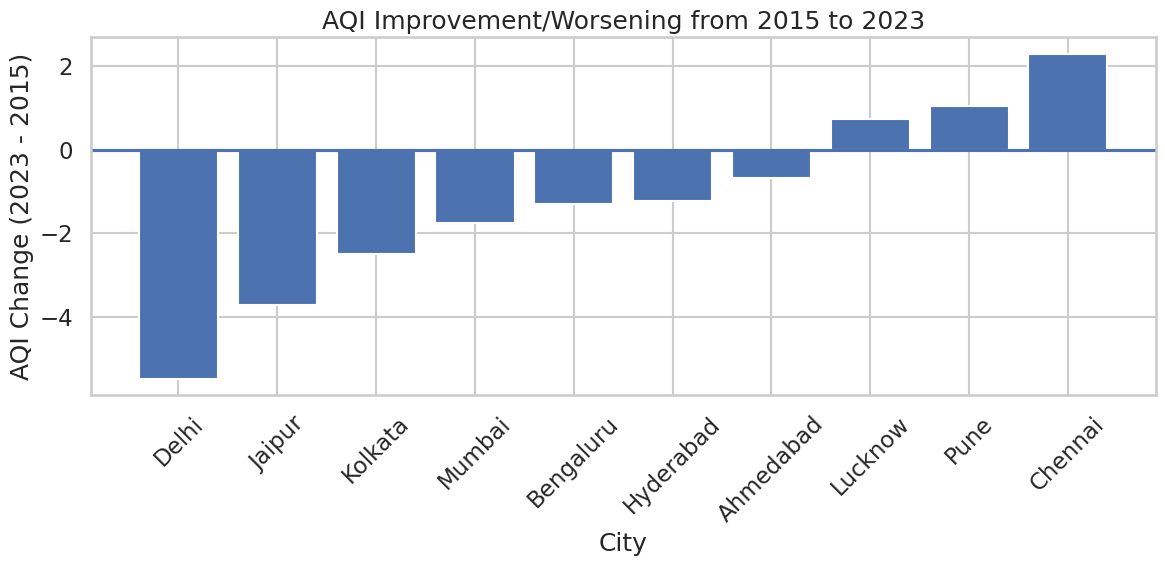

In [54]:
plt.figure(figsize=(12,6))
plt.bar(comparison['city'], comparison['AQI Change (2023-2015)'])
plt.xticks(rotation=45)
plt.xlabel("City")
plt.ylabel("AQI Change (2023 - 2015)")
plt.title("AQI Improvement/Worsening from 2015 to 2023")
plt.axhline(0)
plt.tight_layout()
plt.show()

# How is AQI trend in summer vs winter seasons?

In [55]:
# Make sure 'date' is in datetime format
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# Define seasons
def get_season(month):
    if month in [11, 12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5, 6]:
        return "Summer"
    else:
        return None

df['season'] = df['month'].apply(get_season)

# Keep only Summer and Winter months
df_season = df[df['season'].notnull()]

# Group by city, year, and season, then take average AQI
season_aqi = df_season.groupby(['city', 'year', 'season'])['aqi'].mean().reset_index()

# Pivot to get Winter and Summer side by side
comparison = season_aqi.pivot_table(index=['city','year'], columns='season', values='aqi')

# Calculate Winter - Summer difference
comparison['Winter - Summer'] = comparison['Winter'] - comparison['Summer']

# Optional: reset index for easier viewing
comparison = comparison.reset_index()

display(comparison)

season,city,year,Summer,Winter,Winter - Summer
0,Ahmedabad,2015,92.672131,88.108333,-4.563798
1,Ahmedabad,2016,86.155738,94.264463,8.108725
2,Ahmedabad,2017,84.795082,88.175000,3.379918
3,Ahmedabad,2018,88.426230,87.175000,-1.251230
4,Ahmedabad,2019,85.475410,83.933333,-1.542077
5,Ahmedabad,2020,91.122951,90.586777,-0.536174
6,Ahmedabad,2021,81.319672,92.133333,10.813661
7,Ahmedabad,2022,84.549180,84.358333,-0.190847
8,Ahmedabad,2023,90.065574,89.200000,-0.865574
9,Bengaluru,2015,91.860656,91.066667,-0.793989


In [56]:
df_long = comparison.melt(
    id_vars=['city', 'year'],
    value_vars=['Summer', 'Winter'],
    var_name='Season',
    value_name='AQI'
)

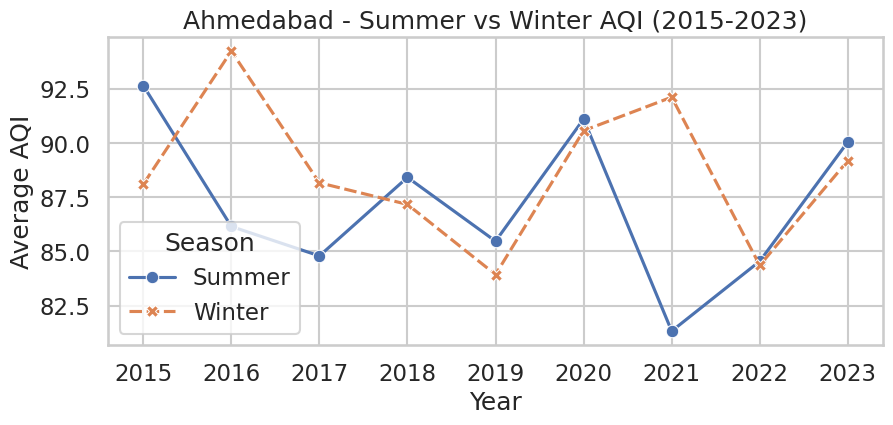

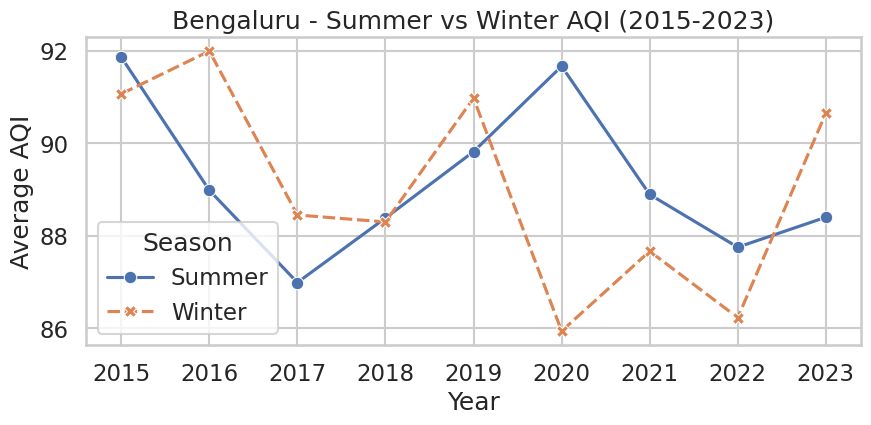

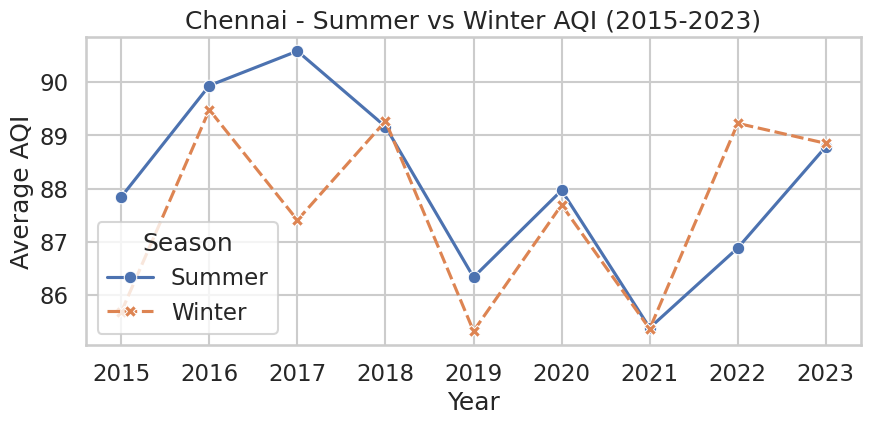

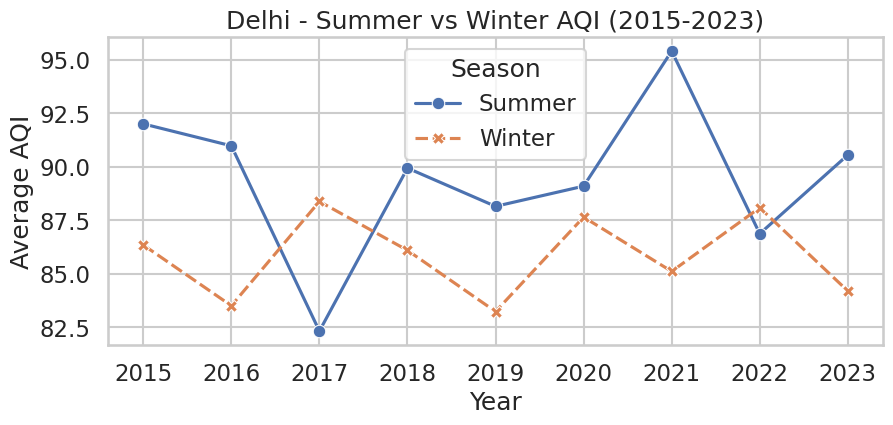

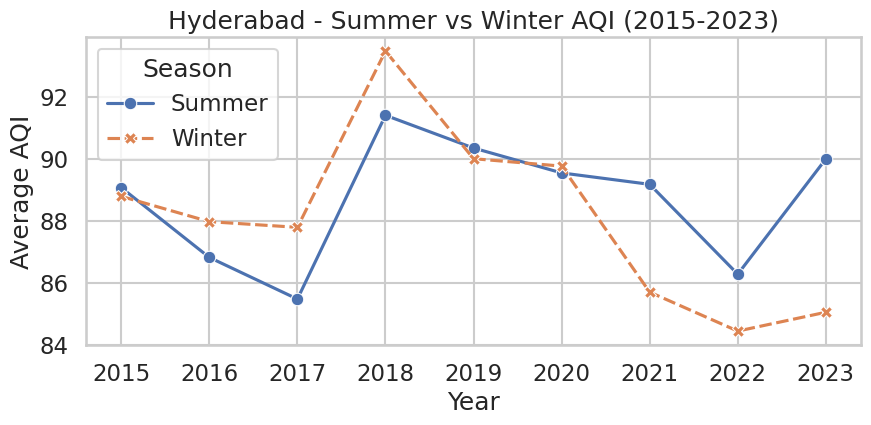

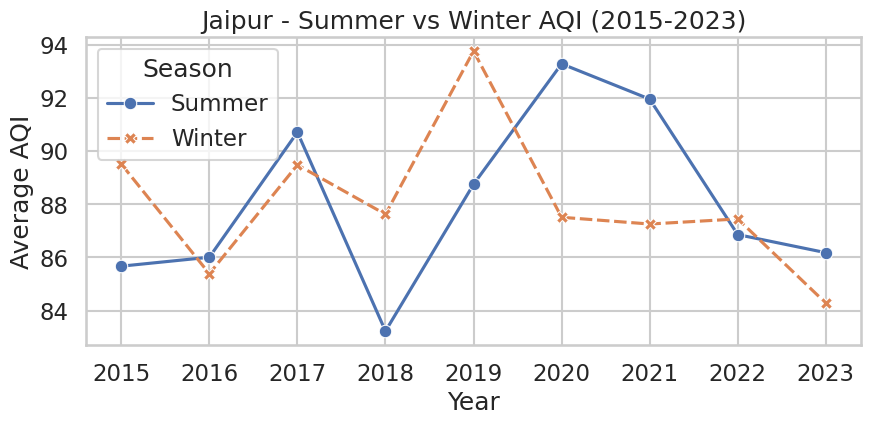

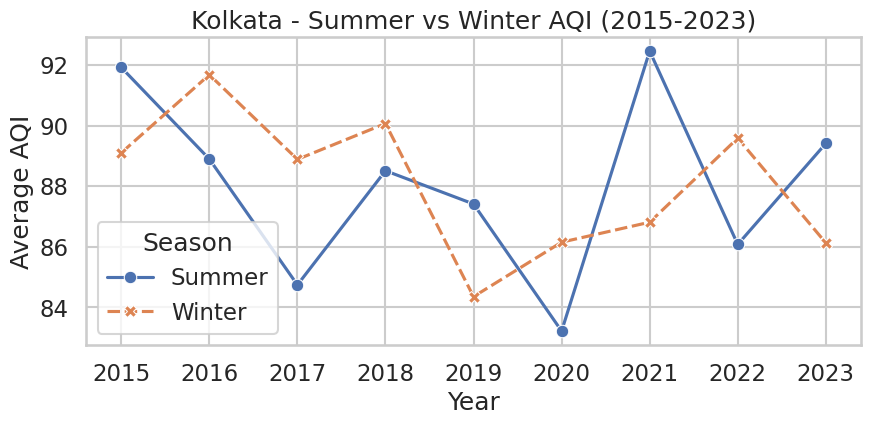

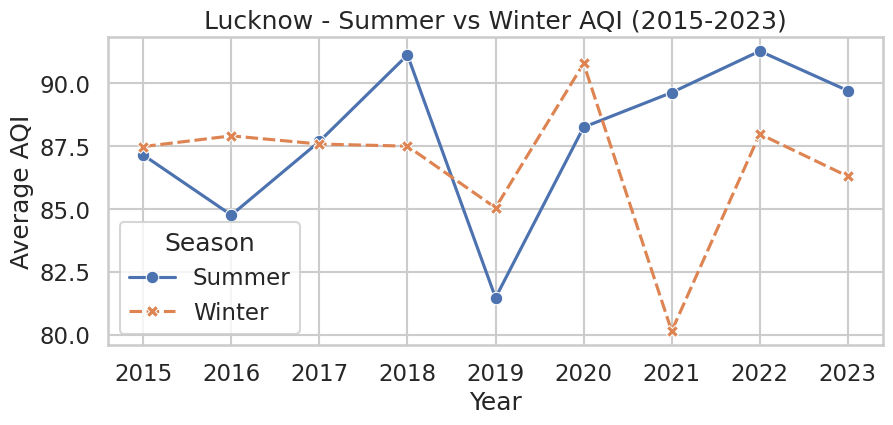

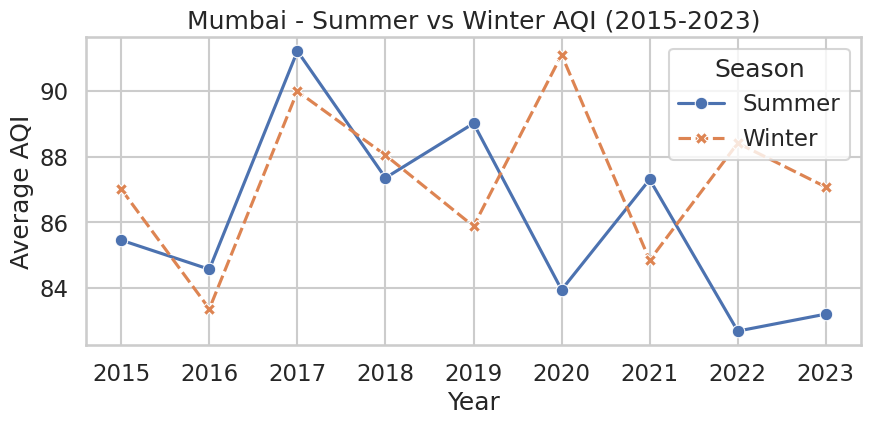

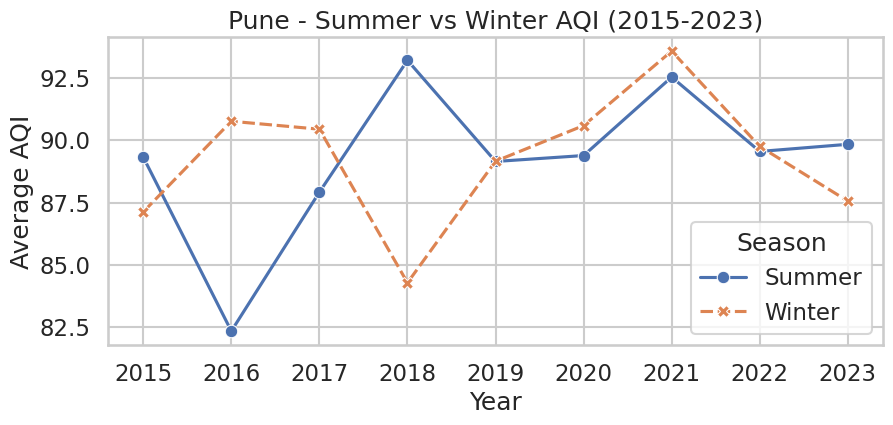

In [57]:
cities = comparison['city'].unique()

for city in cities:
    df_city = df_long[df_long['city'] == city]
    plt.figure(figsize=(10, 4))
    sns.lineplot(data=df_city, x='year', y='AQI', hue='Season', style='Season', markers=True)
    plt.title(f'{city} - Summer vs Winter AQI (2015-2023)')
    plt.xlabel('Year')
    plt.ylabel('Average AQI')
    plt.xticks(range(2015, 2024))
    plt.legend(title='Season')
    plt.show()

# Between all these pm2.5, pm10, no2, so2, co, o3 polutants what is the most significant polutant for bad aqi ?

Correlation of Pollutants with AQI:
pm25    0.979949
pm10    0.958303
o3      0.043559
no2     0.037541
co      0.004749
so2     0.000379
Name: aqi, dtype: float64


/tmp/ipykernel_683/3920979826.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=aqi_correlation.index, y=aqi_correlation.values, palette='viridis')


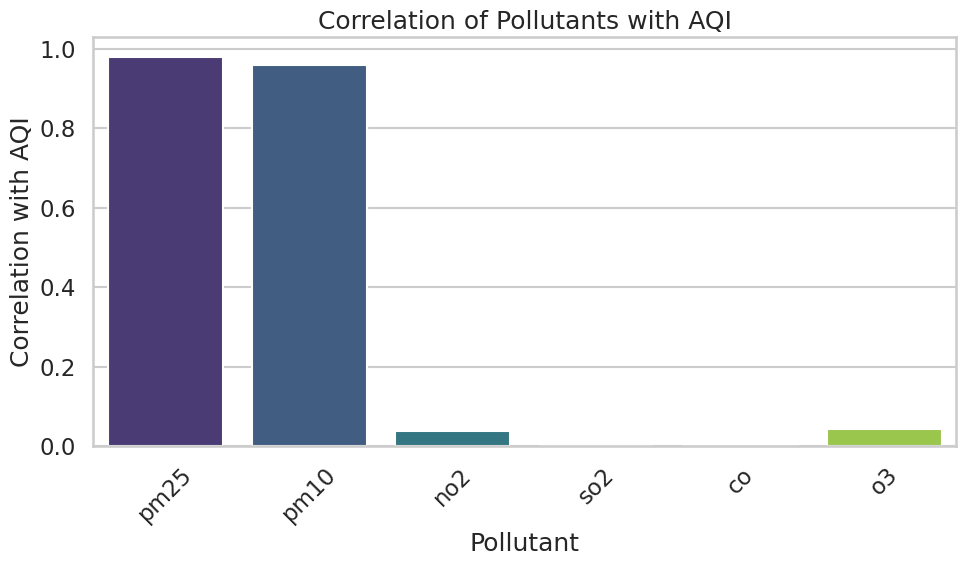

In [58]:
pollutants = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3']
aqi_correlation = dataset[pollutants + ['aqi']].corr()['aqi'].drop('aqi')

print("Correlation of Pollutants with AQI:")
print(aqi_correlation.sort_values(ascending=False))

plt.figure(figsize=(10, 6))
sns.barplot(x=aqi_correlation.index, y=aqi_correlation.values, palette='viridis')
plt.title('Correlation of Pollutants with AQI')
plt.xlabel('Pollutant')
plt.ylabel('Correlation with AQI')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

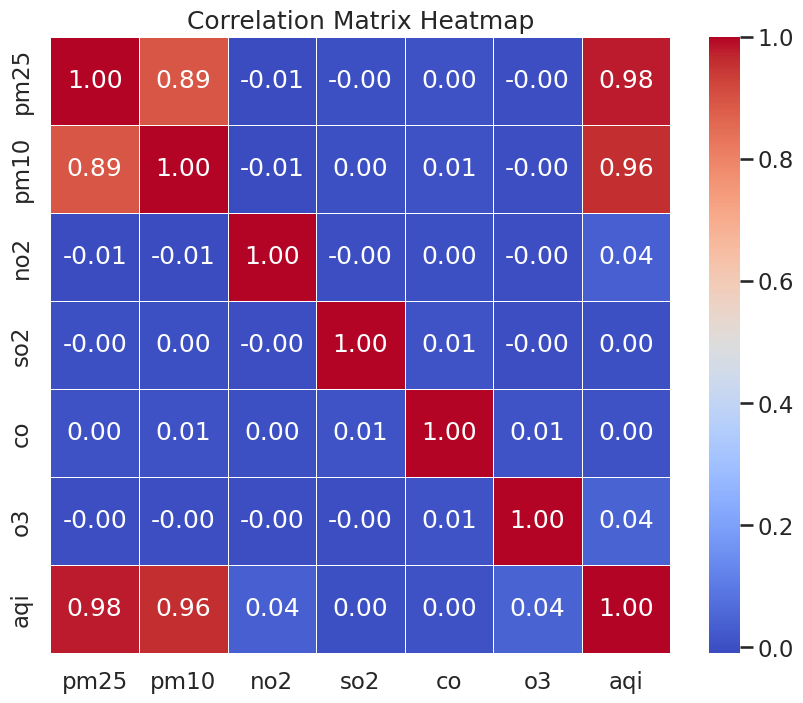

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.show()